# Round 5 Price Alpha Research

This notebook is meant for alpha discovery, not execution diagnostics. It looks for tradable structure: constant baskets, stationary spreads, lead-lag relationships, regime shifts, and simple mid-price backtest proxies.

In [1]:

from pathlib import Path
from itertools import combinations, product
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from sklearn.decomposition import PCA
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.vector_ar.vecm import coint_johansen

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid", context="notebook")

BASE = Path.cwd()
if not (BASE / "prices_round_5_day_2.csv").exists():
    BASE = BASE / "ROUND_5"

DAYS = [2, 3, 4]
DAY_OFFSET = 1_000_000

GROUPS = {
    "GALAXY": ["GALAXY_SOUNDS_DARK_MATTER", "GALAXY_SOUNDS_BLACK_HOLES", "GALAXY_SOUNDS_PLANETARY_RINGS", "GALAXY_SOUNDS_SOLAR_WINDS", "GALAXY_SOUNDS_SOLAR_FLAMES"],
    "SLEEP": ["SLEEP_POD_SUEDE", "SLEEP_POD_LAMB_WOOL", "SLEEP_POD_POLYESTER", "SLEEP_POD_NYLON", "SLEEP_POD_COTTON"],
    "MICROCHIP": ["MICROCHIP_CIRCLE", "MICROCHIP_OVAL", "MICROCHIP_SQUARE", "MICROCHIP_RECTANGLE", "MICROCHIP_TRIANGLE"],
    "PEBBLES": ["PEBBLES_XS", "PEBBLES_S", "PEBBLES_M", "PEBBLES_L", "PEBBLES_XL"],
    "ROBOT": ["ROBOT_VACUUMING", "ROBOT_MOPPING", "ROBOT_DISHES", "ROBOT_LAUNDRY", "ROBOT_IRONING"],
    "UV_VISOR": ["UV_VISOR_YELLOW", "UV_VISOR_AMBER", "UV_VISOR_ORANGE", "UV_VISOR_RED", "UV_VISOR_MAGENTA"],
    "TRANSLATOR": ["TRANSLATOR_SPACE_GRAY", "TRANSLATOR_ASTRO_BLACK", "TRANSLATOR_ECLIPSE_CHARCOAL", "TRANSLATOR_GRAPHITE_MIST", "TRANSLATOR_VOID_BLUE"],
    "PANEL": ["PANEL_1X2", "PANEL_2X2", "PANEL_1X4", "PANEL_2X4", "PANEL_4X4"],
    "OXYGEN": ["OXYGEN_SHAKE_MORNING_BREATH", "OXYGEN_SHAKE_EVENING_BREATH", "OXYGEN_SHAKE_MINT", "OXYGEN_SHAKE_CHOCOLATE", "OXYGEN_SHAKE_GARLIC"],
    "SNACKPACK": ["SNACKPACK_CHOCOLATE", "SNACKPACK_VANILLA", "SNACKPACK_PISTACHIO", "SNACKPACK_STRAWBERRY", "SNACKPACK_RASPBERRY"],
}
PRODUCT_TO_GROUP = {p: g for g, ps in GROUPS.items() for p in ps}
PRODUCTS = [p for ps in GROUPS.values() for p in ps]

def short(name):
    for prefix in ["GALAXY_SOUNDS_", "SLEEP_POD_", "MICROCHIP_", "PEBBLES_", "ROBOT_", "UV_VISOR_", "TRANSLATOR_", "PANEL_", "OXYGEN_SHAKE_", "SNACKPACK_"]:
        name = name.replace(prefix, "")
    return name

def load_prices():
    frames = []
    for day in DAYS:
        df = pd.read_csv(BASE / f"prices_round_5_day_{day}.csv", sep=";")
        df["global_ts"] = df["timestamp"] + (day - DAYS[0]) * DAY_OFFSET
        frames.append(df)
    prices = pd.concat(frames, ignore_index=True)
    prices["group"] = prices["product"].map(PRODUCT_TO_GROUP)
    mids = prices.pivot_table(index="global_ts", columns="product", values="mid_price").sort_index().ffill()
    return prices, mids

def load_trades():
    frames = []
    for day in DAYS:
        df = pd.read_csv(BASE / f"trades_round_5_day_{day}.csv", sep=";")
        df["day"] = day
        df["global_ts"] = df["timestamp"] + (day - DAYS[0]) * DAY_OFFSET
        frames.append(df)
    trades = pd.concat(frames, ignore_index=True)
    trades["group"] = trades["symbol"].map(PRODUCT_TO_GROUP)
    return trades

def fast_adf(x, max_points=6000):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna()
    if len(x) > max_points:
        x = x.iloc[:: max(1, len(x) // max_points)]
    if len(x) < 50 or x.nunique() < 4:
        return np.nan
    try:
        return adfuller(x, maxlag=8, autolag=None)[1]
    except Exception:
        return np.nan

def zscore(s, window=500):
    s = pd.Series(s)
    mu = s.rolling(window, min_periods=window//3).mean()
    sd = s.rolling(window, min_periods=window//3).std()
    return (s - mu) / sd

prices, mids = load_prices()
rets_1 = np.log(mids).diff()
rets_10 = np.log(mids.iloc[::10]).diff().dropna()
print(prices.shape, mids.shape)


(1500000, 19) (30000, 50)


## 1. Group-Level Map

Normalized prices and group sums make the first-level structure visible.

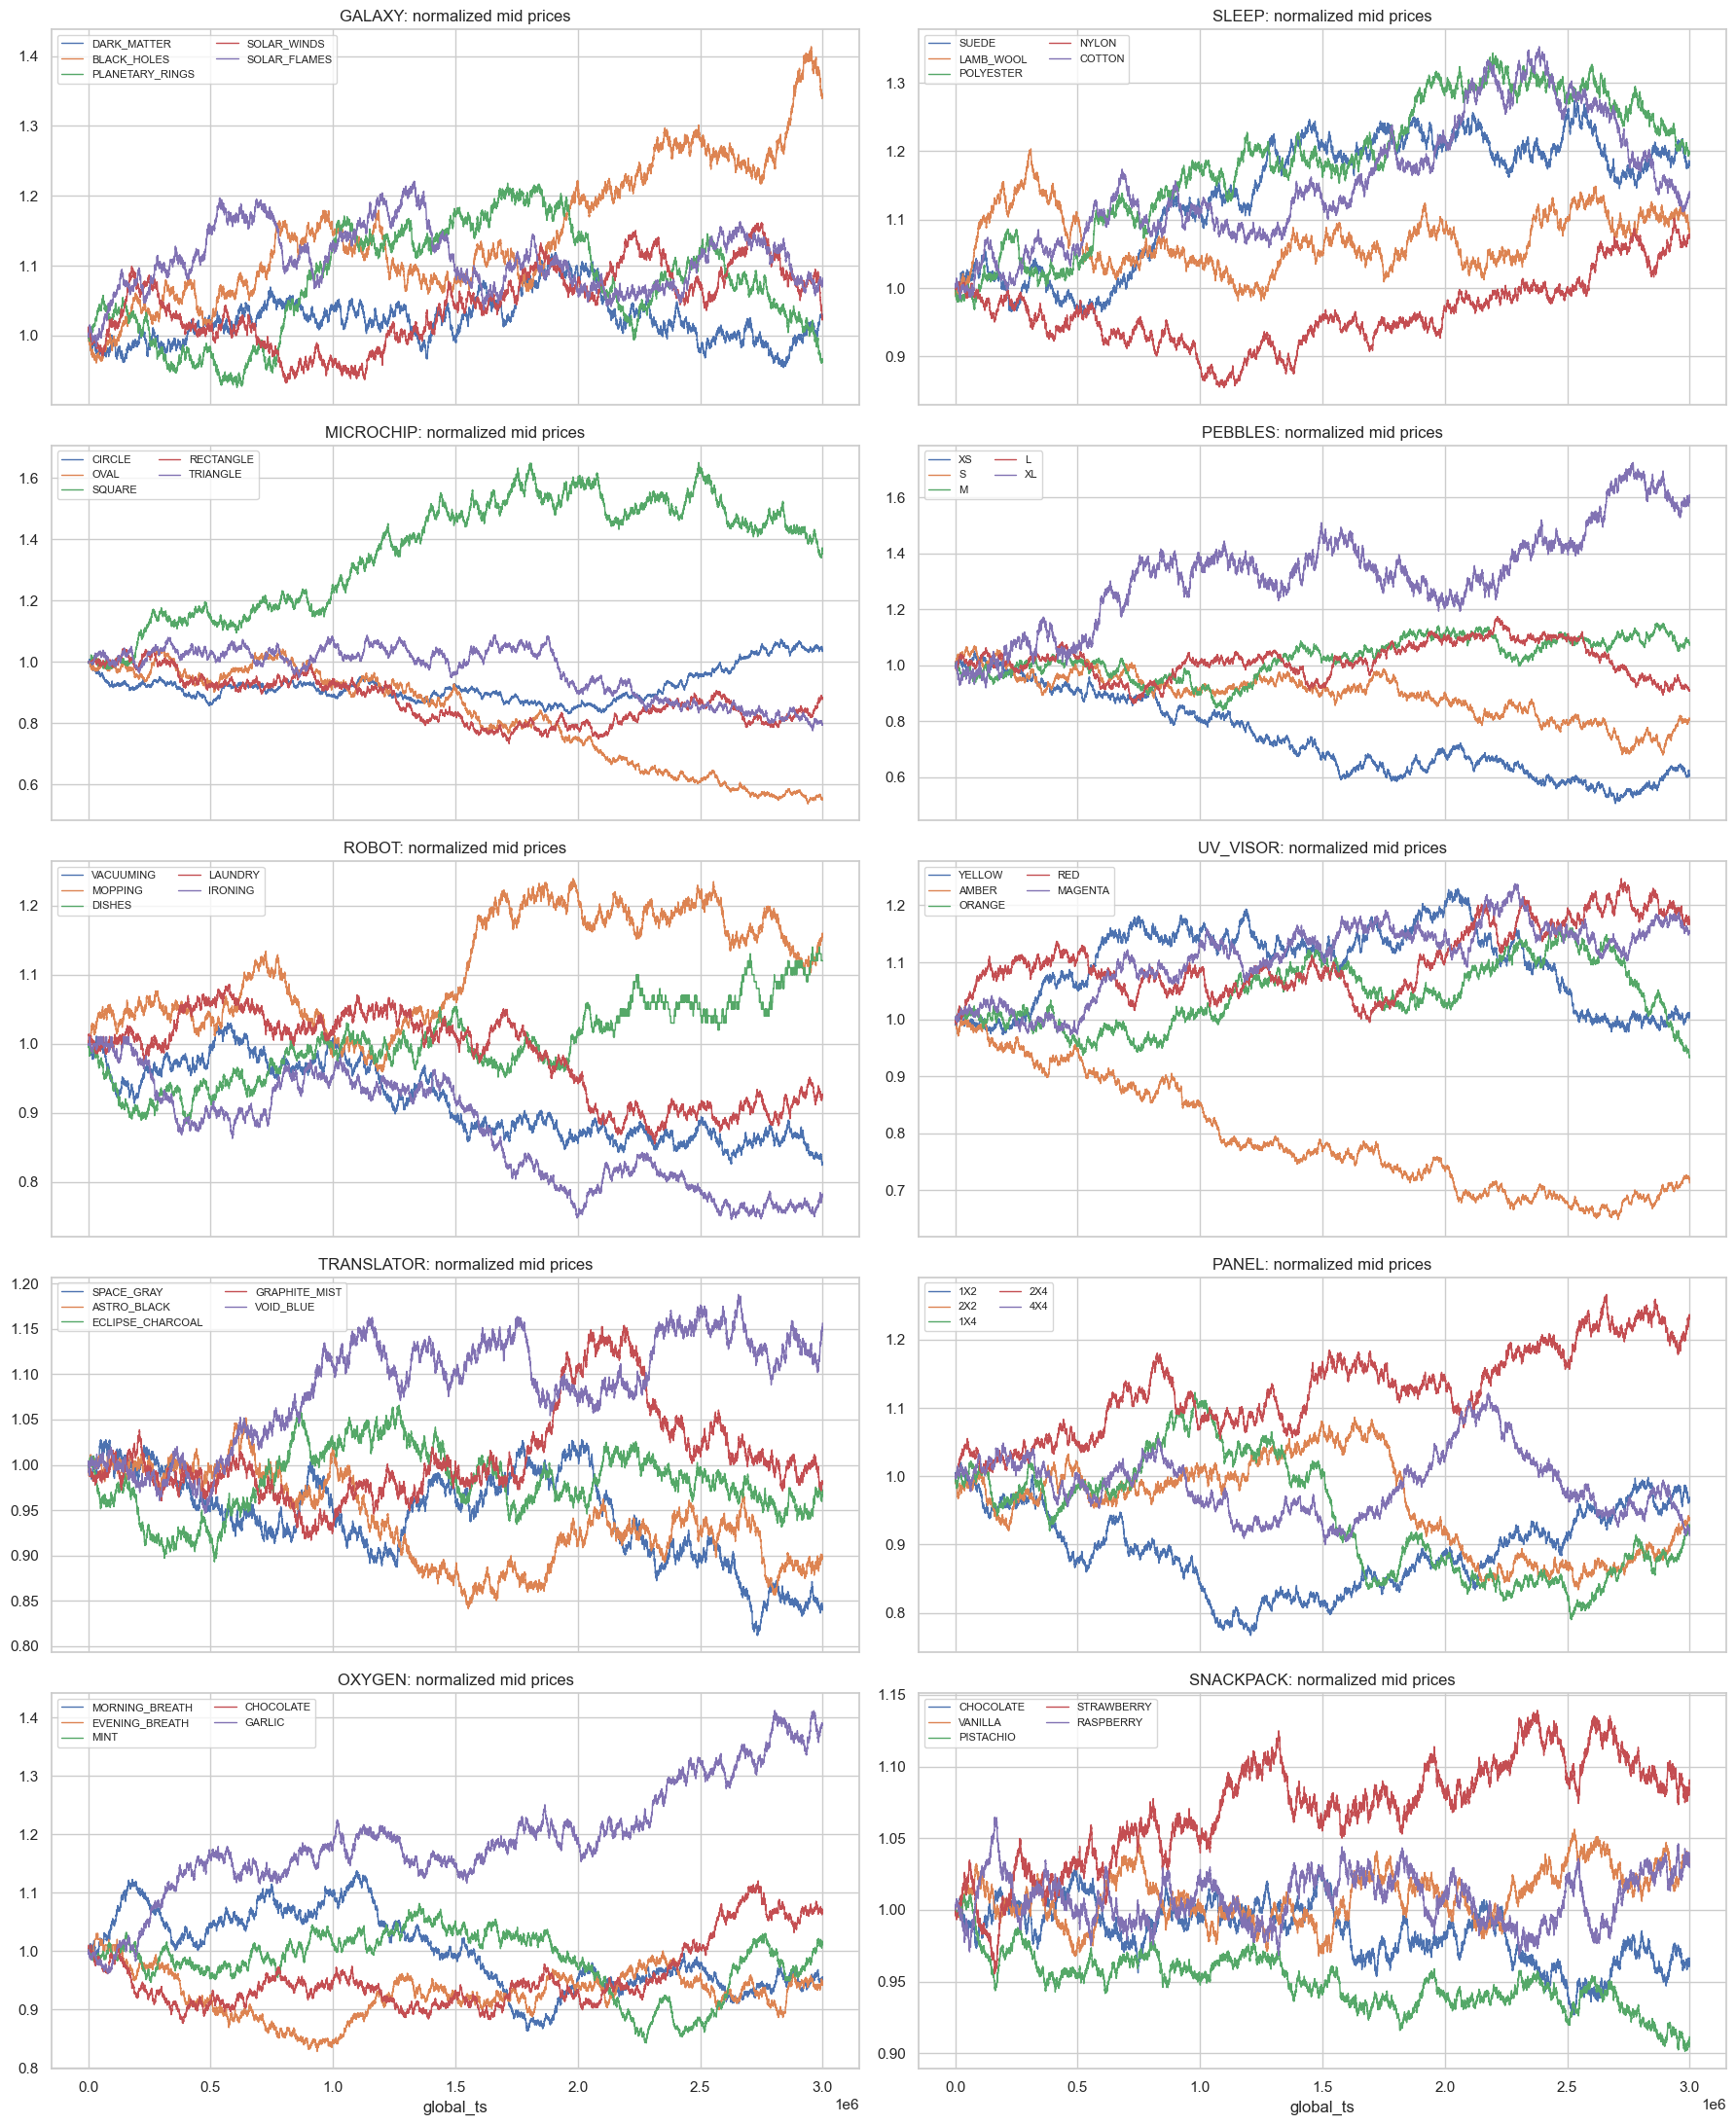

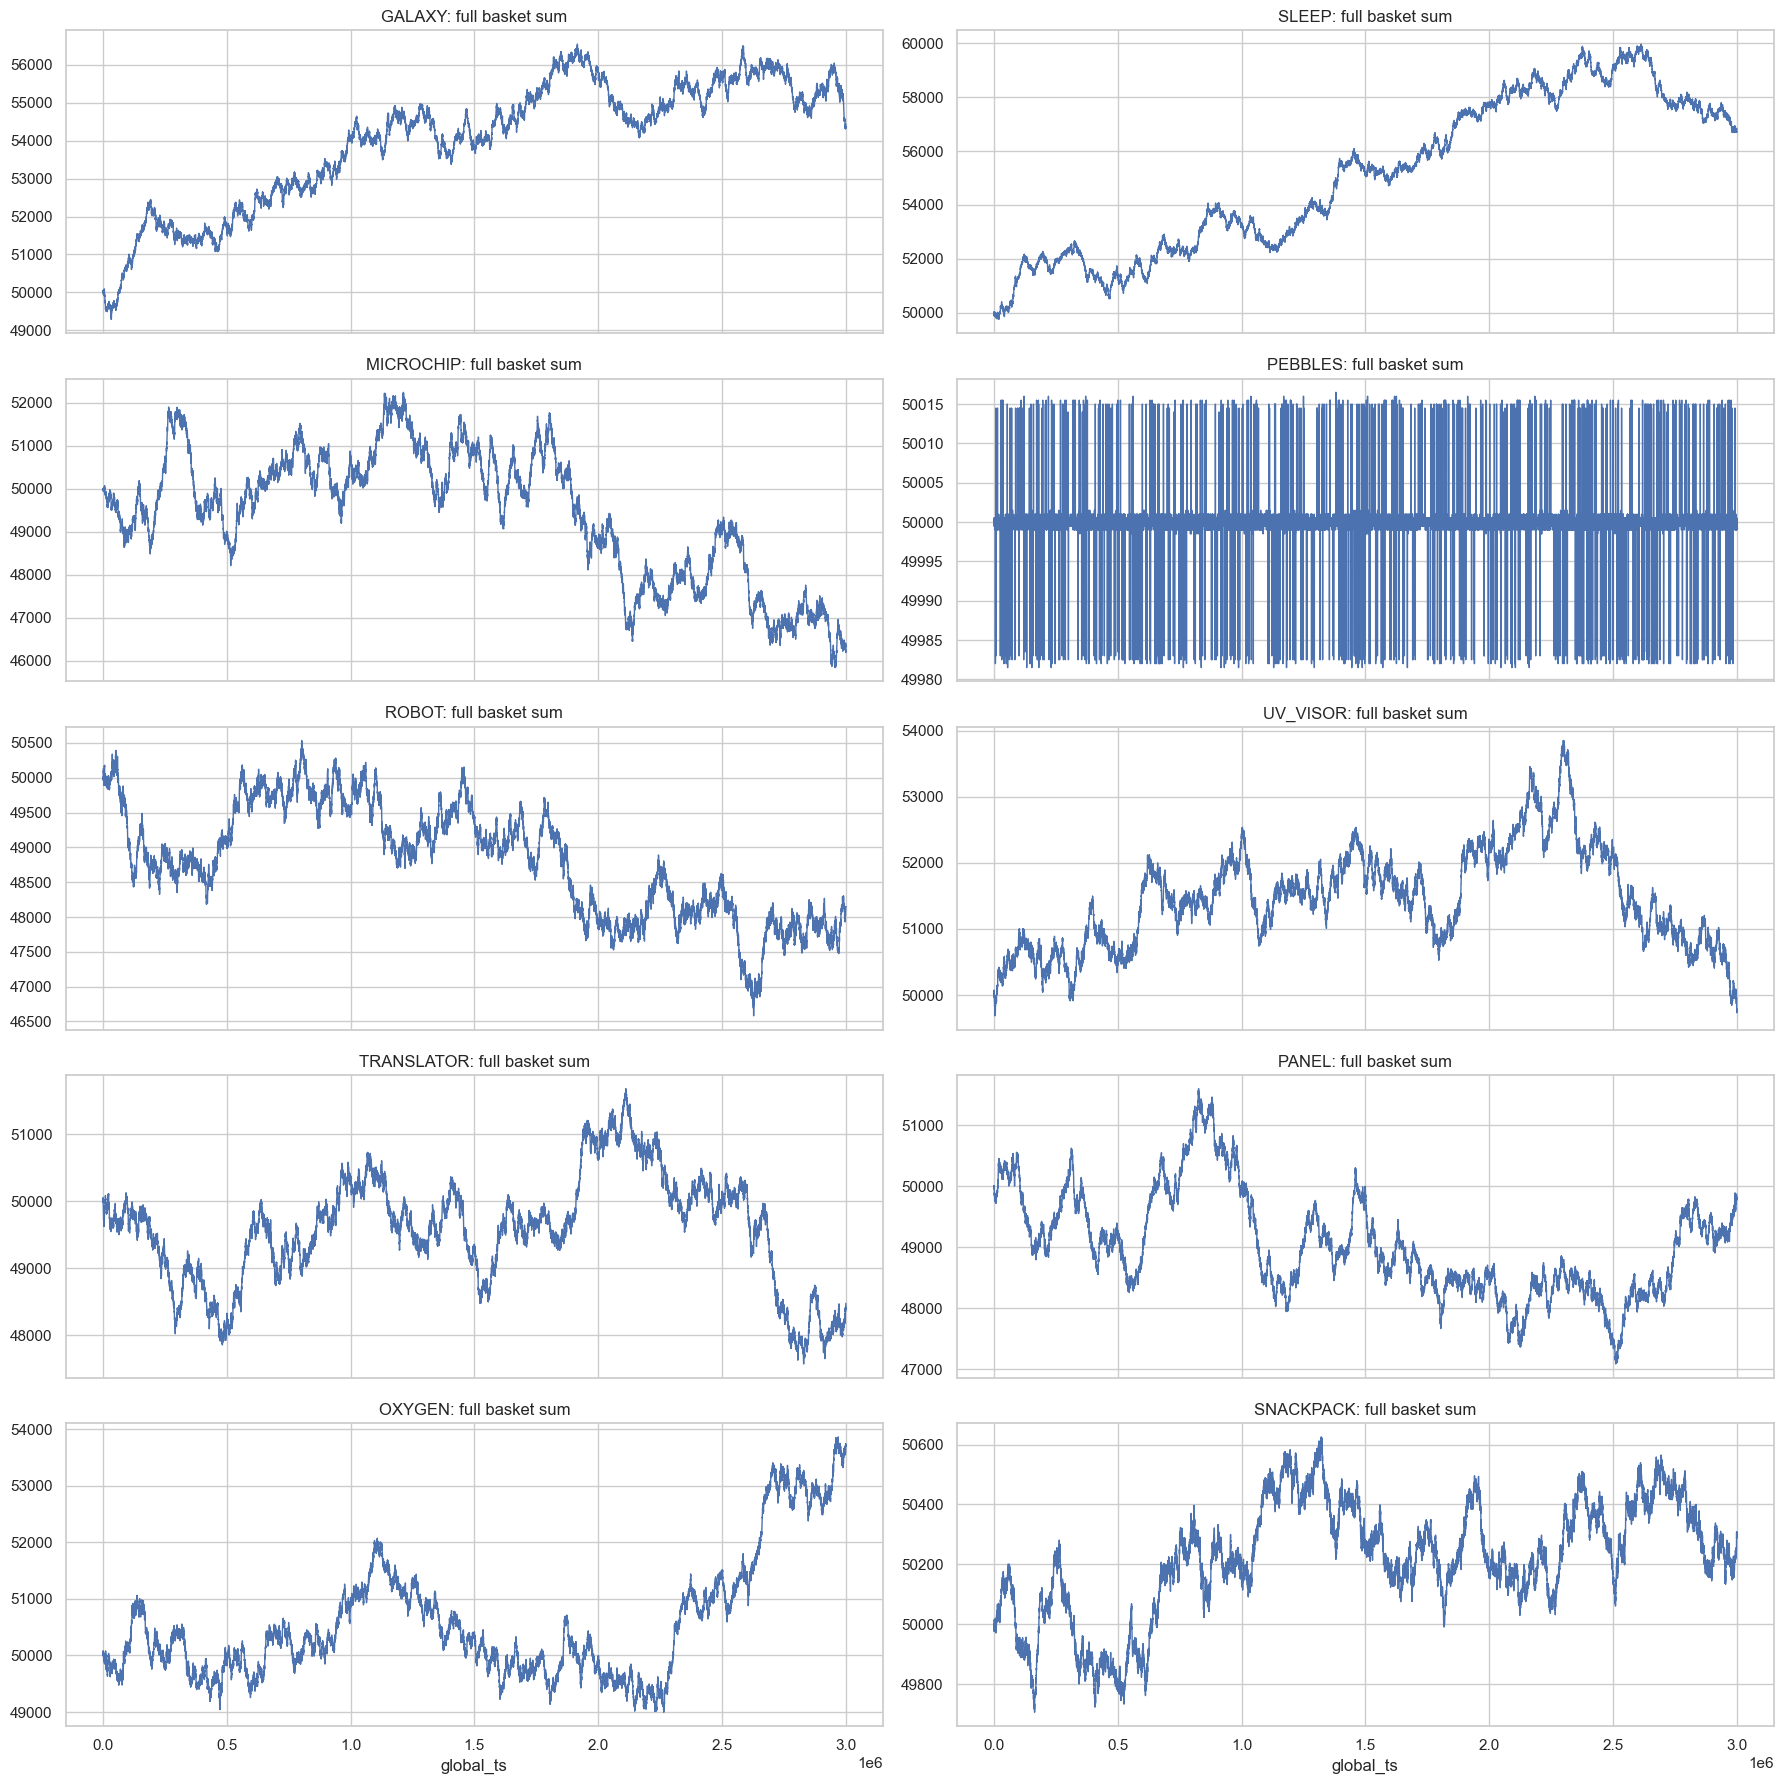

,group,sum_mean,sum_std,sum_range,adf_p
3,PEBBLES,49999.939583,2.798488,35.0,0.000000
9,SNACKPACK,50220.938600,189.579405,919.5,0.065142
5,UV_VISOR,51470.749700,742.334701,4163.0,0.107929
4,ROBOT,48809.635883,807.827900,3954.5,0.134540
6,TRANSLATOR,49574.081950,816.706930,4116.5,0.297370
7,PANEL,49041.000317,850.365162,4514.5,0.161871
8,OXYGEN,50593.261333,1083.101799,4868.5,0.858308
2,MICROCHIP,49408.062733,1501.929900,6398.5,0.623721
0,GALAXY,53990.322750,1645.037970,7254.5,0.126076
1,SLEEP,55103.509633,2855.141116,10225.0,0.419052


In [2]:

fig, axes = plt.subplots(5, 2, figsize=(18, 22), sharex=True)
axes = axes.ravel()
for ax, (group, products) in zip(axes, GROUPS.items()):
    norm = mids[products].dropna() / mids[products].dropna().iloc[0]
    norm.rename(columns=short).plot(ax=ax, linewidth=1)
    ax.set_title(f"{group}: normalized mid prices")
    ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(5, 2, figsize=(18, 18), sharex=True)
axes = axes.ravel()
sum_stats = []
for ax, (group, products) in zip(axes, GROUPS.items()):
    s = mids[products].sum(axis=1)
    sum_stats.append([group, s.mean(), s.std(), s.max() - s.min(), fast_adf(s)])
    s.plot(ax=ax, linewidth=1)
    ax.set_title(f"{group}: full basket sum")
plt.tight_layout()
plt.show()

sum_stats = pd.DataFrame(sum_stats, columns=["group", "sum_mean", "sum_std", "sum_range", "adf_p"]).sort_values("sum_std")
sum_stats


## 2. Subset Sum Discovery

Search every within-group subset for unusually stable sums. This catches hidden basket conservation beyond the full group.

,group,n,combo,products,mean,std,range,cv,adf_p
103,PEBBLES,5,XS + S + M + L + XL,PEBBLES_XS|PEBBLES_S|PEBBLES_M|PEBBLES_L|PEBBL...,49999.939583,2.798488,35.0,0.000056,0.000000
259,SNACKPACK,5,CHOCOLATE + VANILLA + PISTACHIO + STRAWBERRY +...,SNACKPACK_CHOCOLATE|SNACKPACK_VANILLA|SNACKPAC...,50220.938600,189.579405,919.5,0.003775,0.065142
234,SNACKPACK,2,CHOCOLATE + VANILLA,SNACKPACK_CHOCOLATE|SNACKPACK_VANILLA,19940.674117,76.198313,342.0,0.003821,0.408613
257,SNACKPACK,4,CHOCOLATE + PISTACHIO + STRAWBERRY + RASPBERRY,SNACKPACK_CHOCOLATE|SNACKPACK_PISTACHIO|SNACKP...,40123.636133,230.547035,1185.5,0.005746,0.022403
255,SNACKPACK,4,CHOCOLATE + VANILLA + PISTACHIO + RASPBERRY,SNACKPACK_CHOCOLATE|SNACKPACK_VANILLA|SNACKPAC...,39514.330100,238.845880,1174.0,0.006045,0.172801
246,SNACKPACK,3,CHOCOLATE + VANILLA + RASPBERRY,SNACKPACK_CHOCOLATE|SNACKPACK_VANILLA|SNACKPAC...,30018.486183,197.775109,1245.5,0.006588,0.019614
256,SNACKPACK,4,CHOCOLATE + VANILLA + STRAWBERRY + RASPBERRY,SNACKPACK_CHOCOLATE|SNACKPACK_VANILLA|SNACKPAC...,40725.094683,279.579439,1218.5,0.006865,0.314363
251,SNACKPACK,3,VANILLA + PISTACHIO + RASPBERRY,SNACKPACK_VANILLA|SNACKPACK_PISTACHIO|SNACKPAC...,29670.958450,211.082538,1209.5,0.007114,0.009109
254,SNACKPACK,4,CHOCOLATE + VANILLA + PISTACHIO + STRAWBERRY,SNACKPACK_CHOCOLATE|SNACKPACK_VANILLA|SNACKPAC...,40143.126533,292.190401,1868.5,0.007279,0.004290
253,SNACKPACK,3,PISTACHIO + STRAWBERRY + RASPBERRY,SNACKPACK_PISTACHIO|SNACKPACK_STRAWBERRY|SNACK...,30280.264483,230.816323,1051.0,0.007623,0.185460


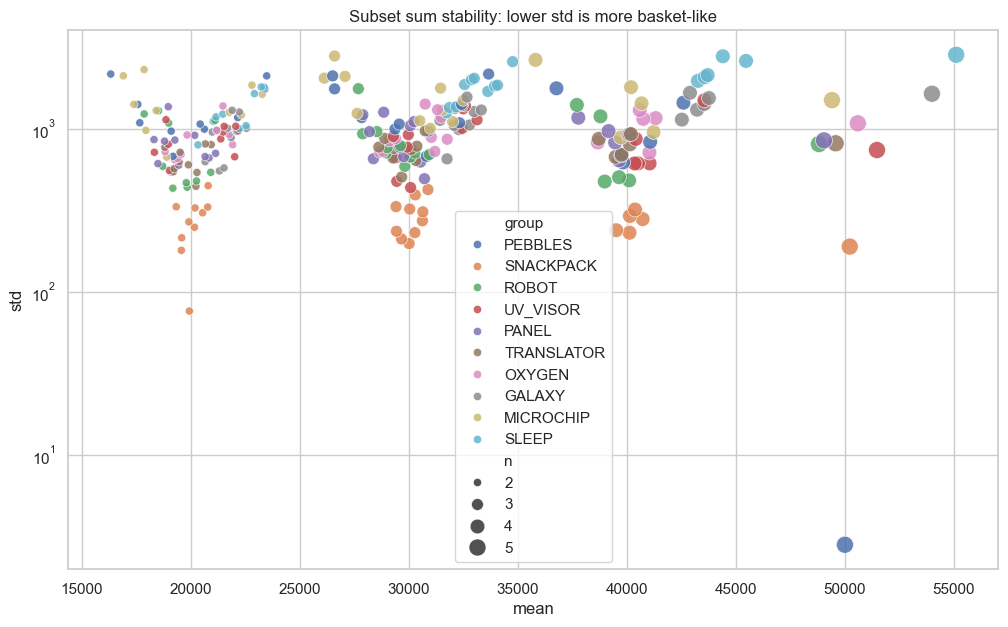

In [3]:

subset_rows = []
for group, products in GROUPS.items():
    for r in range(2, len(products) + 1):
        for combo in combinations(products, r):
            s = mids[list(combo)].sum(axis=1).dropna()
            subset_rows.append({
                "group": group,
                "n": r,
                "combo": " + ".join(short(c) for c in combo),
                "products": "|".join(combo),
                "mean": s.mean(),
                "std": s.std(),
                "range": s.max() - s.min(),
                "cv": s.std() / abs(s.mean()),
                "adf_p": fast_adf(s),
            })
subset = pd.DataFrame(subset_rows).sort_values(["cv", "std"])
display(subset.head(40))

plt.figure(figsize=(12, 7))
sns.scatterplot(data=subset, x="mean", y="std", hue="group", size="n", sizes=(35, 150), alpha=0.85)
plt.yscale("log")
plt.title("Subset sum stability: lower std is more basket-like")
plt.show()


## 3. Minimum-Variance Basket Discovery

For each group, PCA on price levels finds the lowest-variance linear combination. Train/test stability is the important part.

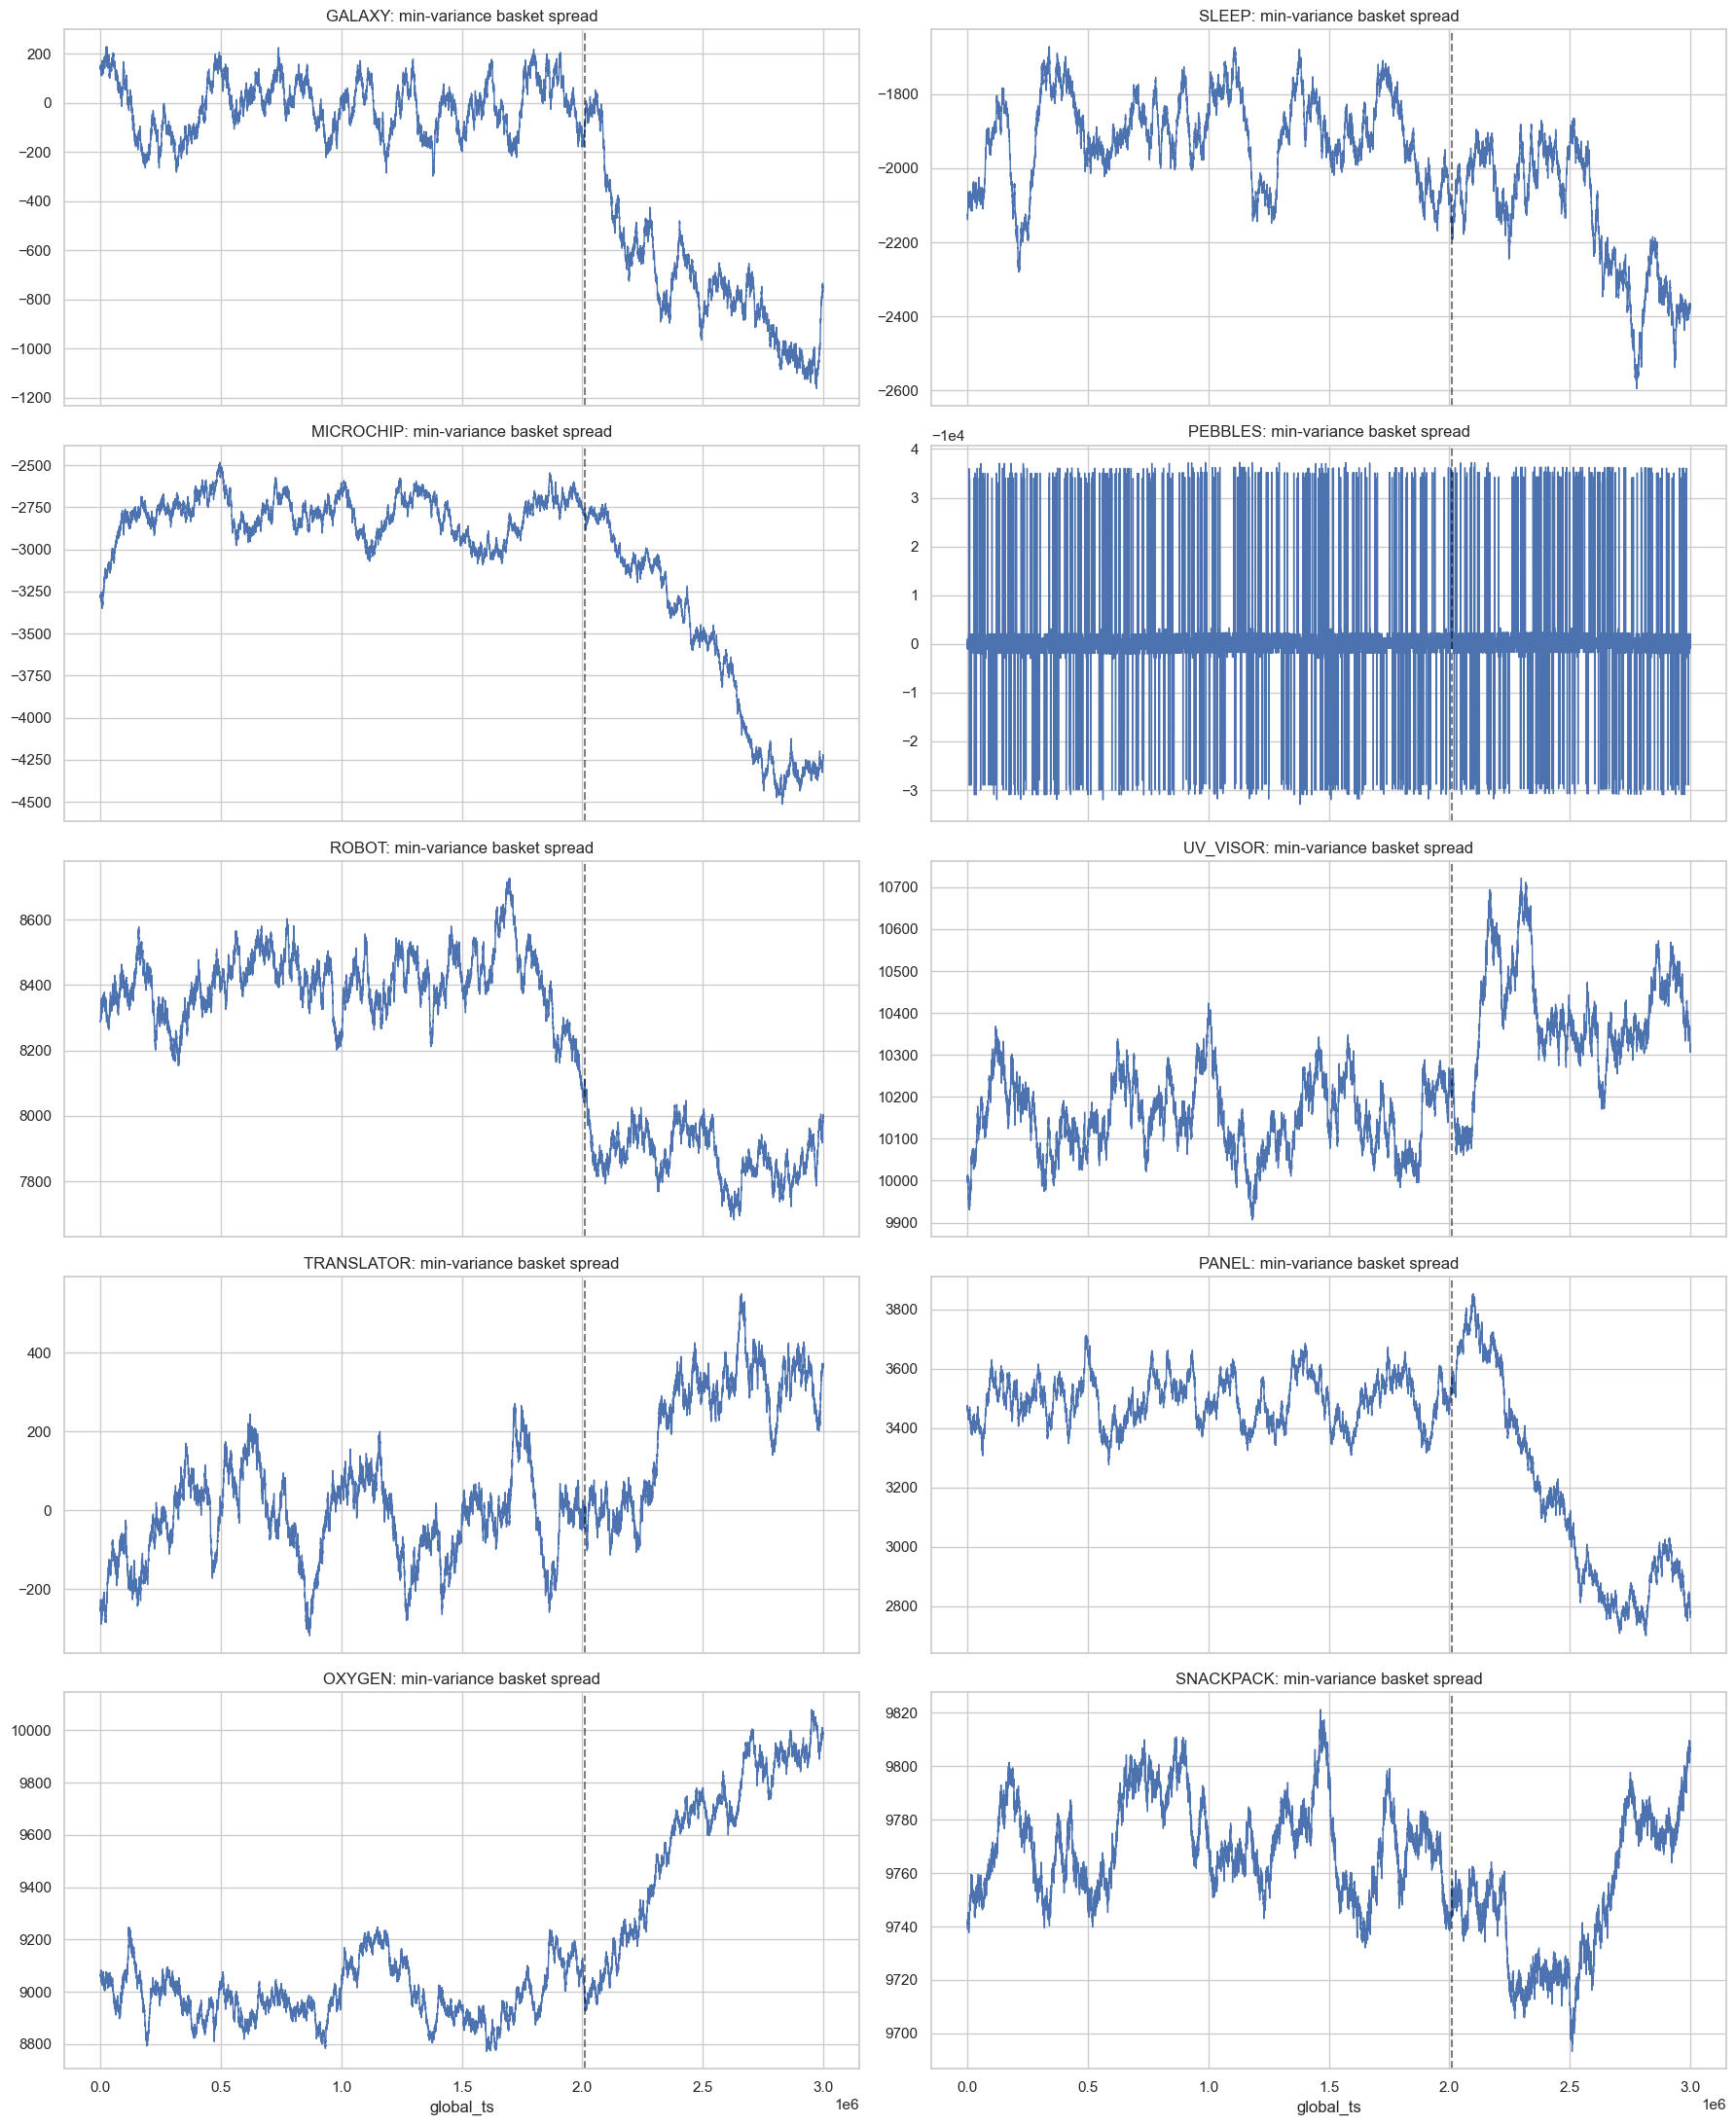

,group,min_var_eigenvalue,train_std,test_std,train_adf,test_adf,test_mean_shift_sigma,weights
3,PEBBLES,1.556813,0.557999,0.563225,0.000000,0.000000,0.012891,XS:-0.200 | S:-0.200 | M:-0.200 | L:-0.200 | X...
4,ROBOT,35368.681569,105.011642,76.193681,0.006735,0.002360,-4.981025,VACUUMING:-0.085 | MOPPING:0.206 | DISHES:0.03...
5,UV_VISOR,25092.493973,87.971851,133.739325,0.000133,0.149403,2.671012,YELLOW:-0.000 | AMBER:0.257 | ORANGE:0.057 | R...
0,GALAXY,32992.796106,109.683400,274.074805,0.000848,0.181856,-6.357038,DARK_MATTER:0.496 | BLACK_HOLES:-0.284 | PLANE...
6,TRANSLATOR,46587.515148,112.776702,159.169695,0.004579,0.369995,2.211456,SPACE_GRAY:-0.141 | ASTRO_BLACK:0.162 | ECLIPS...
8,OXYGEN,42194.052358,102.690231,315.275595,0.009650,0.500884,5.919347,MORNING_BREATH:0.122 | EVENING_BREATH:0.281 | ...
1,SLEEP,53171.725037,115.530811,176.752266,0.029847,0.511761,-1.972950,SUEDE:0.097 | LAMB_WOOL:0.070 | POLYESTER:-0.2...
2,MICROCHIP,34748.779045,129.847018,556.244055,0.000398,0.755318,-6.197329,CIRCLE:-0.665 | OVAL:0.153 | SQUARE:0.043 | RE...
7,PANEL,21915.267577,79.480751,335.955907,0.000054,0.818232,-4.278351,1X2:-0.172 | 2X2:0.245 | 1X4:-0.038 | 2X4:-0.1...
9,SNACKPACK,779.321769,17.239007,25.711543,0.027679,0.906598,-1.359988,CHOCOLATE:0.454 | VANILLA:0.409 | PISTACHIO:-0...


In [4]:

pca_rows = []
fig, axes = plt.subplots(5, 2, figsize=(18, 22), sharex=True)
axes = axes.ravel()
for ax, (group, products) in zip(axes, GROUPS.items()):
    X = mids[products].dropna()
    n = len(X)
    train = X.iloc[: int(0.67*n)]
    test = X.iloc[int(0.67*n):]
    Xc = train - train.mean()
    cov = np.cov(Xc.values.T)
    vals, vecs = np.linalg.eigh(cov)
    w = vecs[:, np.argmin(vals)]
    w = w / np.sum(np.abs(w))
    train_spread = (train @ w)
    test_spread = (test @ w)
    full_spread = (X @ w)
    pca_rows.append({
        "group": group,
        "min_var_eigenvalue": vals.min(),
        "train_std": train_spread.std(),
        "test_std": test_spread.std(),
        "train_adf": fast_adf(train_spread),
        "test_adf": fast_adf(test_spread),
        "test_mean_shift_sigma": (test_spread.mean() - train_spread.mean()) / train_spread.std(),
        "weights": " | ".join(f"{short(p)}:{wi:.3f}" for p, wi in zip(products, w)),
    })
    full_spread.plot(ax=ax, linewidth=1)
    ax.axvline(test.index[0], color="black", linestyle="--", alpha=0.5)
    ax.set_title(f"{group}: min-variance basket spread")
plt.tight_layout()
plt.show()

pca_df = pd.DataFrame(pca_rows).sort_values(["test_adf", "test_std"])
display(pca_df)


## 4. Pair Spread Train/Test Validation

OLS hedge ratios are fitted only on the first 67% of data, then evaluated on the holdout period.

,group,pair,asset_a,asset_b,beta,intercept,train_adf,test_adf,train_std,test_std,mean_shift_sigma,acf1
45,ROBOT,MOPPING ~ LAUNDRY,ROBOT_MOPPING,ROBOT_LAUNDRY,-1.377520,24853.610099,0.160363,0.000206,617.905003,258.777388,-1.090413,0.999598
41,ROBOT,VACUUMING ~ DISHES,ROBOT_VACUUMING,ROBOT_DISHES,-0.395164,13269.625860,0.389370,0.017730,429.362562,152.129337,-1.016092,0.999609
55,UV_VISOR,AMBER ~ RED,UV_VISOR_AMBER,UV_VISOR_RED,0.602911,1967.018819,0.290219,0.025152,809.440035,288.957723,-2.716067,0.999965
17,SLEEP,POLYESTER ~ NYLON,SLEEP_POD_POLYESTER,SLEEP_POD_NYLON,-1.094967,21623.130496,0.929212,0.027894,746.806795,282.509736,3.120560,0.999921
49,ROBOT,LAUNDRY ~ IRONING,ROBOT_LAUNDRY,ROBOT_IRONING,0.118598,9134.334229,0.111049,0.030916,273.827452,198.873468,-3.801968,0.999838
62,TRANSLATOR,SPACE_GRAY ~ GRAPHITE_MIST,TRANSLATOR_SPACE_GRAY,TRANSLATOR_GRAPHITE_MIST,0.421673,5492.084393,0.086469,0.032329,301.790290,308.350316,-3.138882,0.999816
59,UV_VISOR,RED ~ MAGENTA,UV_VISOR_RED,UV_VISOR_MAGENTA,-0.218963,13085.518447,0.004731,0.037102,260.867650,272.781158,4.772471,0.999845
30,PEBBLES,XS ~ S,PEBBLES_XS,PEBBLES_S,1.907789,-9901.422606,0.147686,0.084695,986.293218,685.422320,0.814218,0.999445
38,PEBBLES,M ~ XL,PEBBLES_M,PEBBLES_XL,-0.013321,10131.753133,0.781723,0.094492,622.971297,315.509499,1.496589,0.999770
43,ROBOT,VACUUMING ~ IRONING,ROBOT_VACUUMING,ROBOT_IRONING,0.435595,5461.565822,0.306815,0.096550,376.051610,154.403184,-0.686186,0.999553


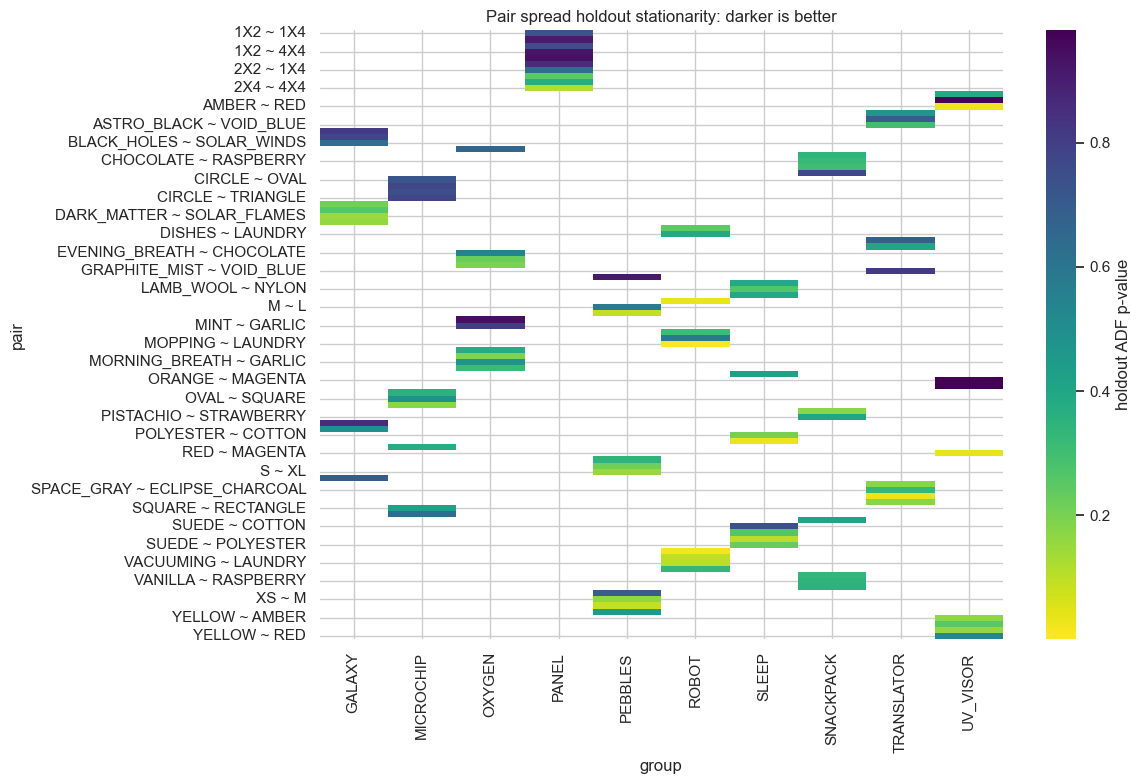

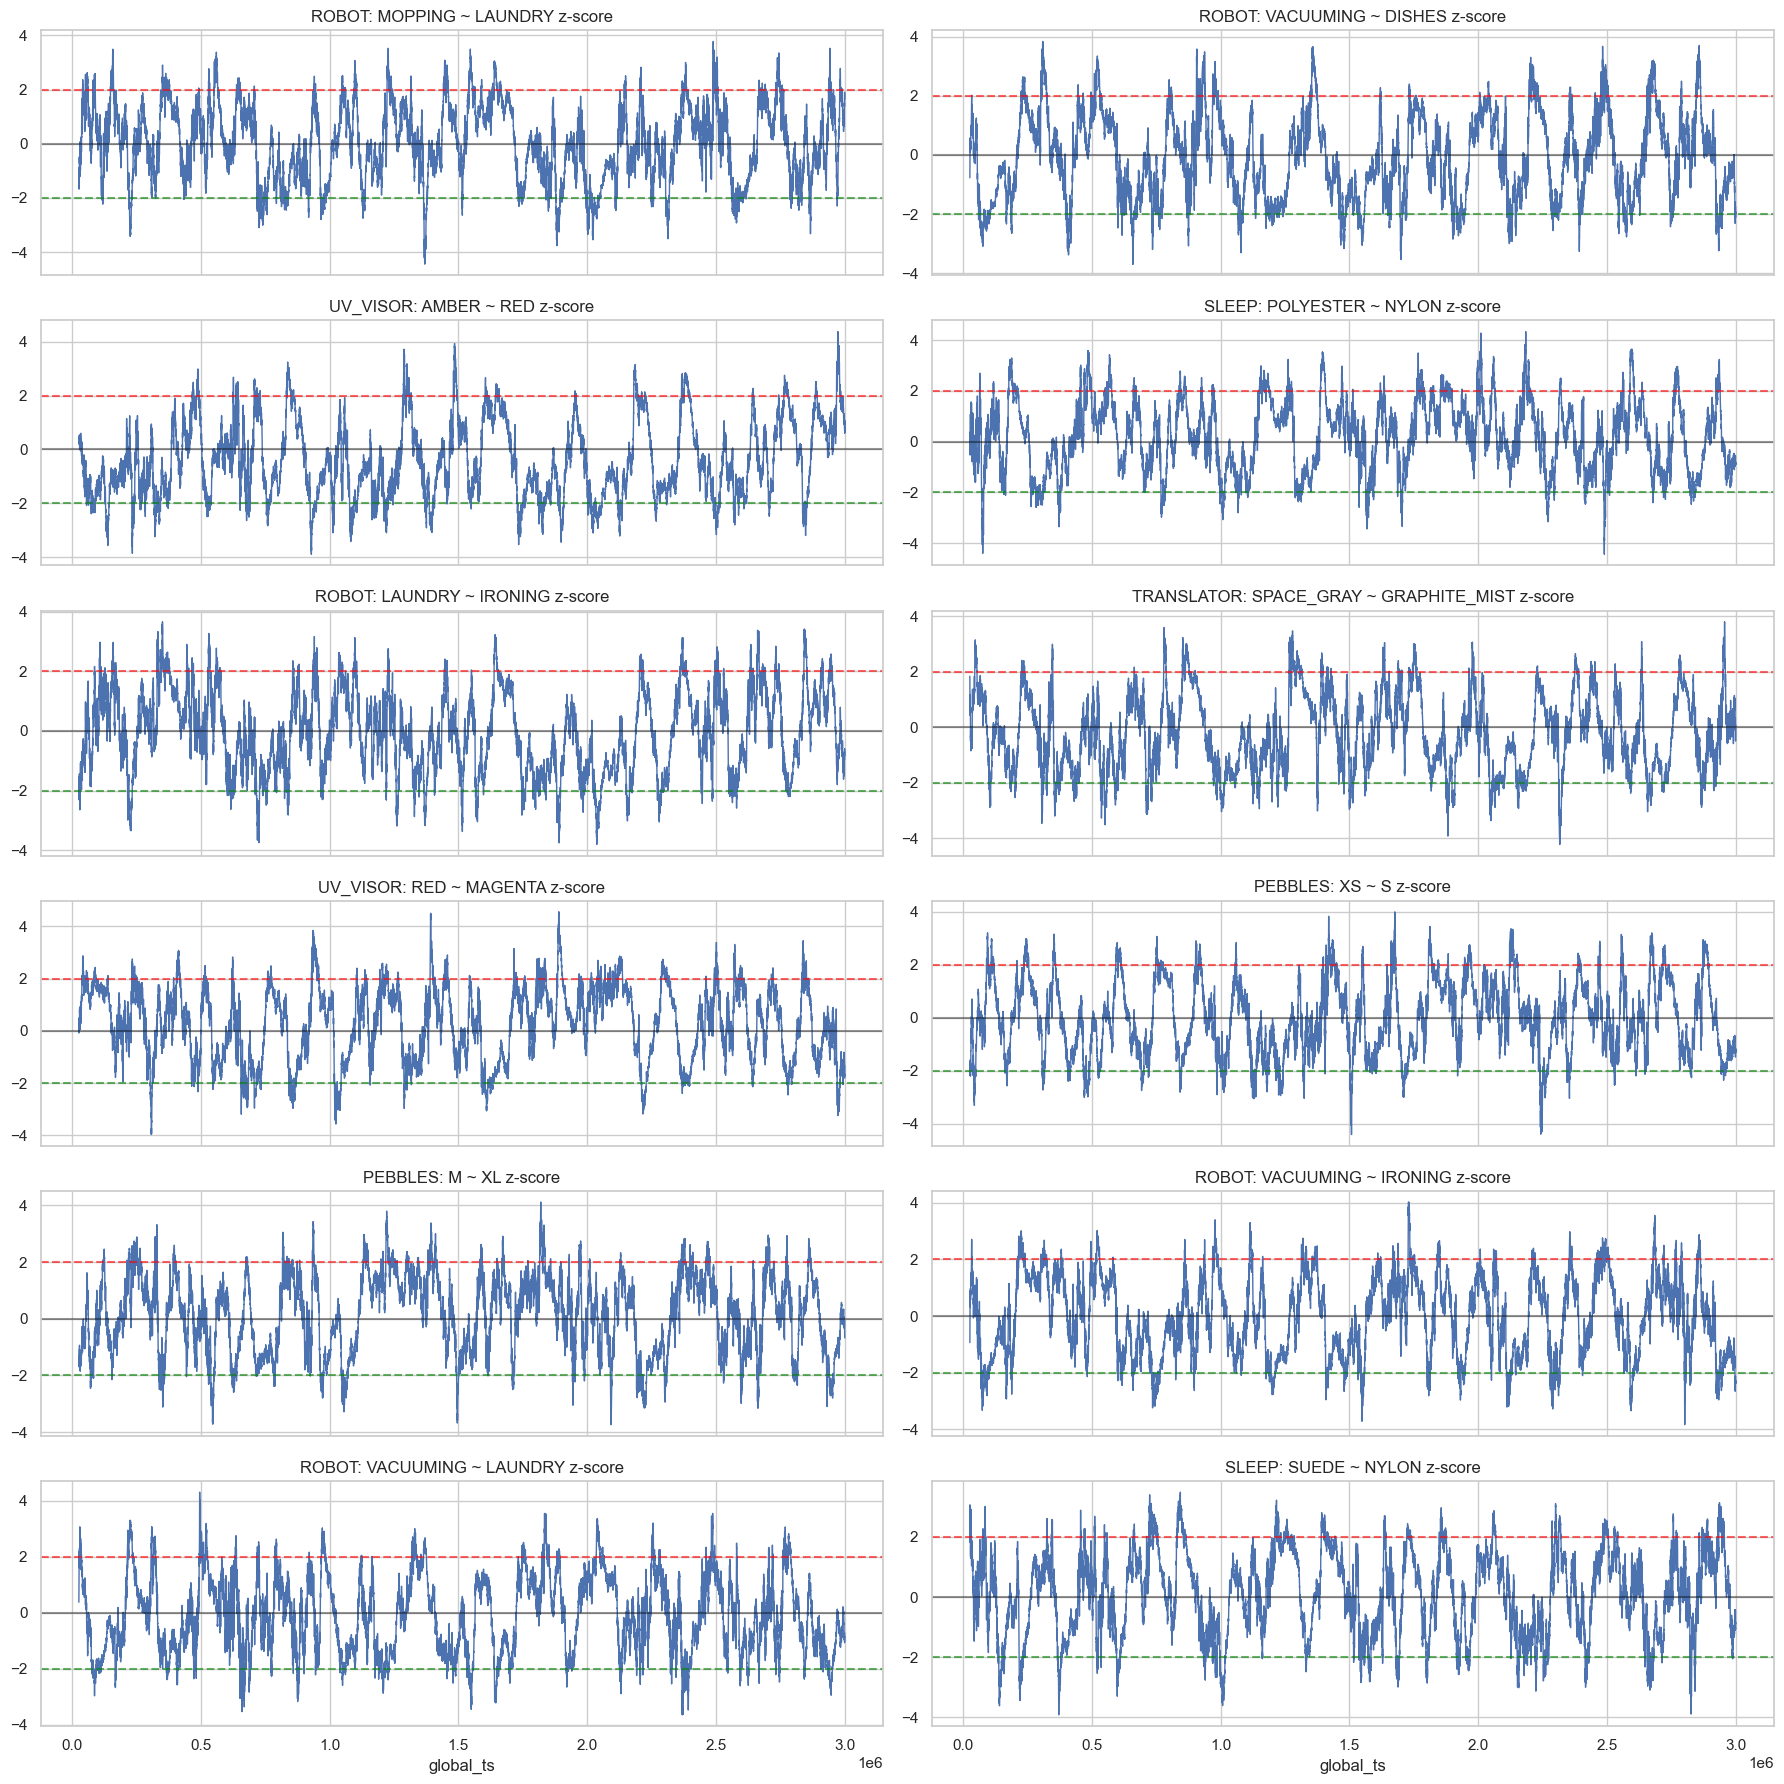

In [5]:

pair_rows = []
pair_spreads = {}
for group, products in GROUPS.items():
    for a, b in combinations(products, 2):
        pair = mids[[a, b]].dropna()
        split = int(0.67 * len(pair))
        train, test = pair.iloc[:split], pair.iloc[split:]
        model = sm.OLS(train[a], sm.add_constant(train[b])).fit()
        beta, intercept = model.params.iloc[1], model.params.iloc[0]
        spread = pair[a] - beta * pair[b] - intercept
        spr_train, spr_test = spread.iloc[:split], spread.iloc[split:]
        key = f"{short(a)} ~ {short(b)}"
        pair_spreads[(group, key)] = spread
        pair_rows.append({
            "group": group, "pair": key, "asset_a": a, "asset_b": b,
            "beta": beta, "intercept": intercept,
            "train_adf": fast_adf(spr_train), "test_adf": fast_adf(spr_test),
            "train_std": spr_train.std(), "test_std": spr_test.std(),
            "mean_shift_sigma": (spr_test.mean() - spr_train.mean()) / spr_train.std(),
            "acf1": spread.autocorr(1),
        })
pair_df = pd.DataFrame(pair_rows).sort_values(["test_adf", "train_adf"])
display(pair_df.head(50))

fig, ax = plt.subplots(figsize=(12, 8))
pivot = pair_df.pivot_table(index="pair", columns="group", values="test_adf", aggfunc="min")
sns.heatmap(pivot, ax=ax, cmap="viridis_r", cbar_kws={"label": "holdout ADF p-value"})
ax.set_title("Pair spread holdout stationarity: darker is better")
plt.tight_layout()
plt.show()

top_pairs = pair_df.head(12)
fig, axes = plt.subplots(6, 2, figsize=(18, 18), sharex=True)
axes = axes.ravel()
for ax, (_, row) in zip(axes, top_pairs.iterrows()):
    spread = pair_spreads[(row.group, row.pair)]
    z = zscore(spread, 800)
    z.plot(ax=ax, linewidth=1)
    ax.axhline(2, color="red", linestyle="--", alpha=0.6)
    ax.axhline(-2, color="green", linestyle="--", alpha=0.6)
    ax.axhline(0, color="black", alpha=0.4)
    ax.set_title(f"{row.group}: {row.pair} z-score")
plt.tight_layout()
plt.show()


## 5. Return Lead-Lag Discovery

Block returns reduce micro-noise. Positive correlation means leader's return tends to be followed by follower in the same direction.

,group,leader_short,follower_short,lag_ts,corr,granger_best_p
40,MICROCHIP,CIRCLE,OVAL,5000,0.095611,0.000025
127,TRANSLATOR,ASTRO_BLACK,VOID_BLUE,2000,-0.056721,0.000274
15,GALAXY,SOLAR_WINDS,SOLAR_FLAMES,7000,0.059187,0.000775
39,SLEEP,COTTON,NYLON,3000,-0.058949,0.005638
87,ROBOT,MOPPING,IRONING,20000,-0.052341,0.006511
136,TRANSLATOR,VOID_BLUE,SPACE_GRAY,1000,0.048636,0.007727
1,GALAXY,DARK_MATTER,PLANETARY_RINGS,7000,-0.069249,0.009187
65,PEBBLES,S,M,3000,-0.061054,0.009740
86,ROBOT,MOPPING,LAUNDRY,1000,-0.046774,0.010224
67,PEBBLES,S,XL,3000,0.063332,0.012528


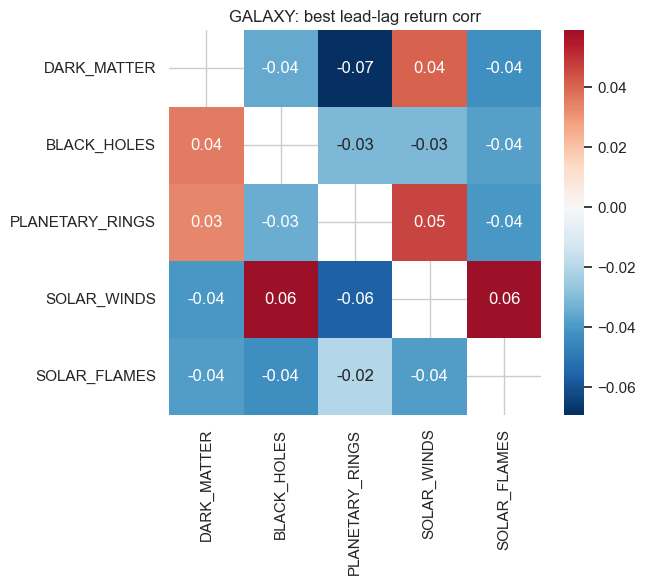

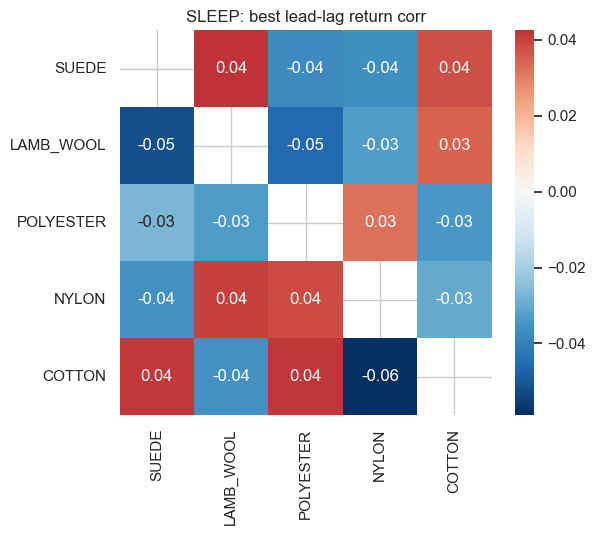

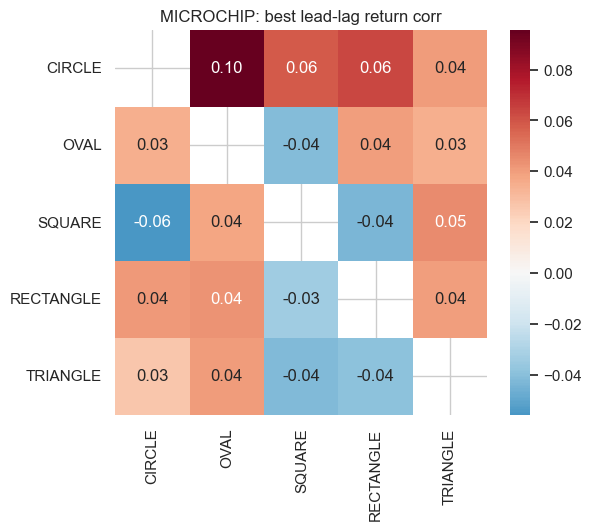

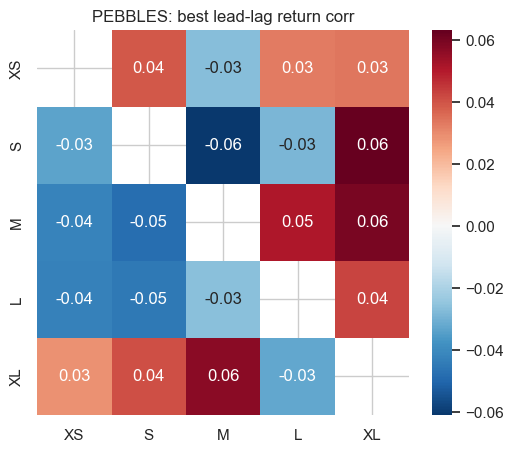

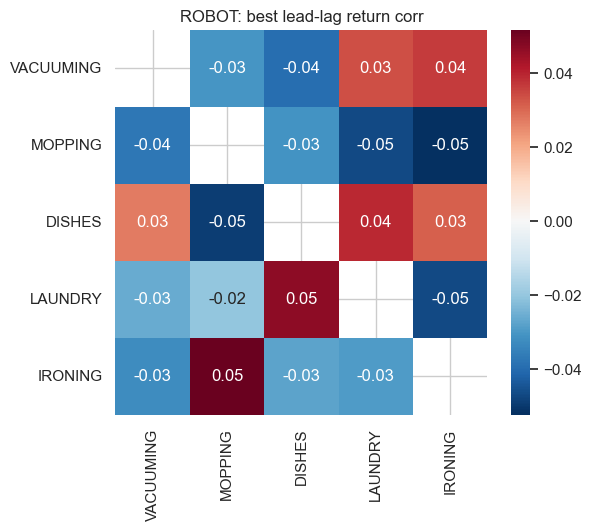

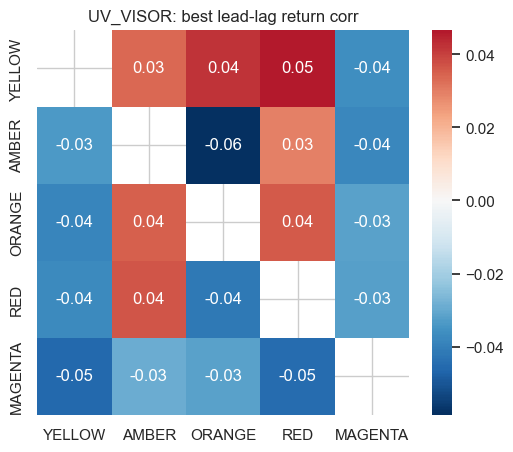

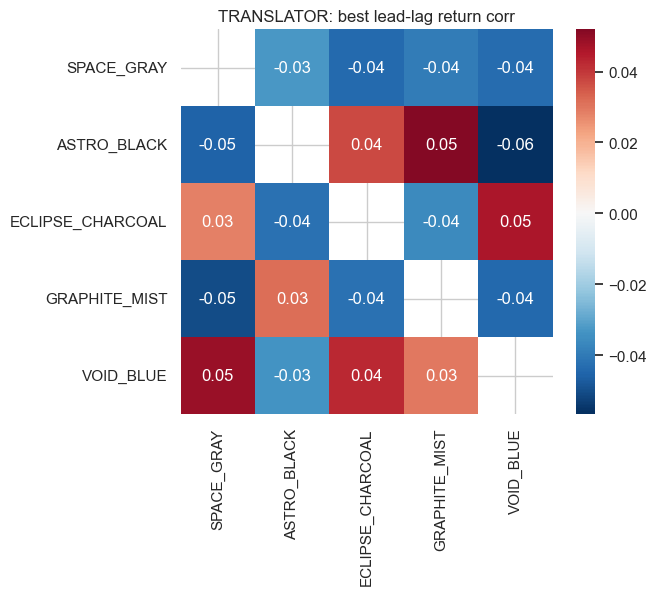

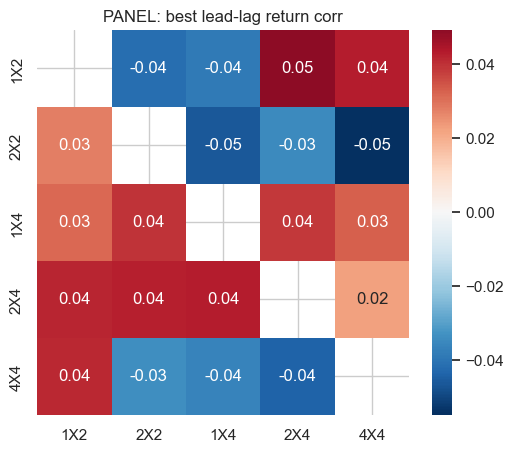

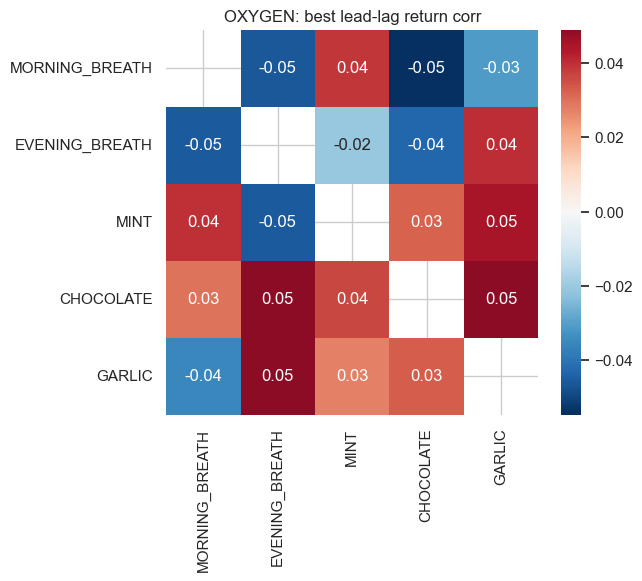

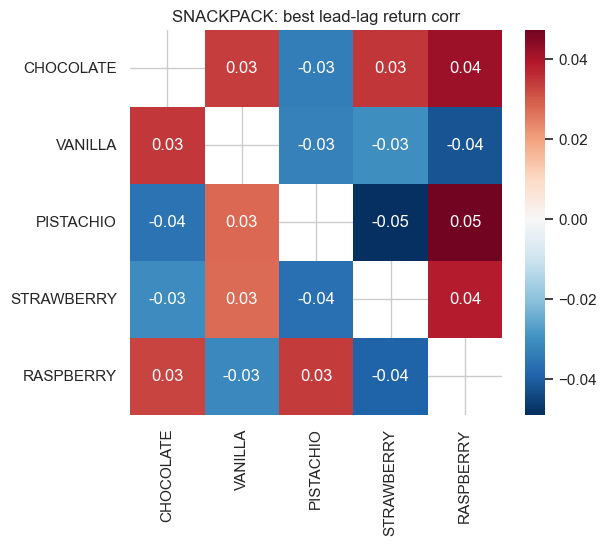

In [6]:

lead_rows = []
MAX_LAG = 20
for group, products in GROUPS.items():
    for leader, follower in product(products, products):
        if leader == follower:
            continue
        x, y = rets_10[leader].values, rets_10[follower].values
        best_lag, best_corr = None, 0
        corrs = {}
        for lag in range(1, MAX_LAG + 1):
            c = np.corrcoef(x[:-lag], y[lag:])[0, 1]
            corrs[lag] = c
            if np.isfinite(c) and abs(c) > abs(best_corr):
                best_lag, best_corr = lag, c
        p = np.nan
        try:
            data = rets_10[[follower, leader]].dropna()
            res = grangercausalitytests(data, maxlag=8, verbose=False)
            pvals = {lag: res[lag][0]["ssr_ftest"][1] for lag in range(1, 9)}
            p = min(pvals.values())
        except Exception:
            pass
        lead_rows.append({
            "group": group,
            "leader": leader,
            "follower": follower,
            "lag_blocks": best_lag,
            "lag_ts": best_lag * 1000,
            "corr": best_corr,
            "granger_best_p": p,
        })
lead_df = pd.DataFrame(lead_rows).sort_values(["granger_best_p", "corr"], ascending=[True, False])
display(lead_df.head(60).assign(leader_short=lambda d: d.leader.map(short), follower_short=lambda d: d.follower.map(short))[["group","leader_short","follower_short","lag_ts","corr","granger_best_p"]])

for group, products in GROUPS.items():
    mat = pd.DataFrame(index=[short(p) for p in products], columns=[short(p) for p in products], dtype=float)
    for _, r in lead_df[lead_df.group == group].iterrows():
        mat.loc[short(r["leader"]), short(r["follower"])] = r["corr"]
    plt.figure(figsize=(6, 5))
    sns.heatmap(mat, center=0, cmap="RdBu_r", annot=True, fmt=".2f")
    plt.title(f"{group}: best lead-lag return corr")
    plt.show()


## 6. Simple Alpha Backtest Proxies

These are mid-price markout tests, not production backtests. They answer: if we trade the signal direction, does future mid move our way?

In [7]:

def lead_lag_markout(leader, follower, lag_blocks, horizon_blocks=5):
    r = rets_10[[leader, follower]].dropna()
    signal = np.sign(r[leader].shift(lag_blocks))
    future = r[follower].rolling(horizon_blocks).sum().shift(-horizon_blocks)
    pnl = (signal * future).dropna()
    return {
        "mean": pnl.mean(),
        "t": pnl.mean() / (pnl.std(ddof=1) / np.sqrt(len(pnl))),
        "hit": (pnl > 0).mean(),
        "n": len(pnl),
    }

ll_scores = []
for _, row in lead_df.head(80).iterrows():
    score = lead_lag_markout(row.leader, row.follower, int(row.lag_blocks), 5)
    ll_scores.append({**row.to_dict(), **score})
ll_scores = pd.DataFrame(ll_scores).sort_values("t", ascending=False)
display(ll_scores.assign(leader_short=lambda d: d.leader.map(short), follower_short=lambda d: d.follower.map(short))[["group","leader_short","follower_short","lag_ts","corr","granger_best_p","mean","t","hit","n"]].head(40))

def spread_reversion_score(spread, window=800, threshold=1.5, horizon=50):
    z = zscore(spread, window)
    signal = -np.sign(z).where(z.abs() > threshold, 0)
    fut = pd.Series(spread).diff(horizon).shift(-horizon)
    # If spread high, short spread, profit when future spread change is negative.
    pnl = (signal * fut).replace([np.inf, -np.inf], np.nan).dropna()
    active = pnl[signal.loc[pnl.index] != 0]
    if len(active) < 30:
        return {"events": len(active), "mean": np.nan, "t": np.nan, "hit": np.nan}
    return {
        "events": len(active),
        "mean": active.mean(),
        "t": active.mean() / (active.std(ddof=1) / np.sqrt(len(active))),
        "hit": (active > 0).mean(),
    }

rev_scores = []
for _, row in pair_df.head(50).iterrows():
    score = spread_reversion_score(pair_spreads[(row.group, row.pair)])
    rev_scores.append({**row.to_dict(), **score})
rev_scores = pd.DataFrame(rev_scores).sort_values("t", ascending=False)
display(rev_scores[["group","pair","test_adf","train_std","test_std","events","mean","t","hit"]].head(30))


,group,leader_short,follower_short,lag_ts,corr,granger_best_p,mean,t,hit,n
10,SNACKPACK,VANILLA,CHOCOLATE,18000,0.034454,0.014381,0.000221,2.650494,0.516465,2976
33,SNACKPACK,VANILLA,RASPBERRY,4000,-0.041853,0.057785,0.000207,2.112564,0.503679,2990
51,MICROCHIP,OVAL,SQUARE,8000,-0.041239,0.099382,0.000343,1.802904,0.501340,2986
75,MICROCHIP,SQUARE,RECTANGLE,8000,-0.043319,0.158167,0.000337,1.759590,0.510382,2986
72,MICROCHIP,OVAL,TRIANGLE,14000,0.034860,0.149936,0.000330,1.718480,0.520805,2980
59,SNACKPACK,CHOCOLATE,PISTACHIO,4000,-0.033641,0.117319,0.000115,1.708271,0.501003,2990
29,MICROCHIP,OVAL,CIRCLE,1000,0.034892,0.052772,0.000209,1.636825,0.502506,2993
7,PEBBLES,S,M,3000,-0.061054,0.009740,0.000294,1.568355,0.509863,2991
71,PANEL,2X4,1X4,18000,0.043027,0.149851,0.000177,1.338494,0.509745,2976
53,SNACKPACK,CHOCOLATE,VANILLA,18000,0.033607,0.100965,0.000101,1.232807,0.508065,2976


,group,pair,test_adf,train_std,test_std,events,mean,t,hit
17,PEBBLES,XS ~ M,0.163240,1090.850572,603.735653,8791,24.593422,15.324131,0.559436
49,PANEL,2X2 ~ 4X4,0.374706,260.905972,443.042934,8927,13.185602,14.101134,0.555170
8,PEBBLES,M ~ XL,0.094492,622.971297,315.509499,9034,14.276456,13.366931,0.562874
28,OXYGEN,EVENING_BREATH ~ GARLIC,0.225059,358.574035,287.309331,9583,7.536875,10.458462,0.531566
32,UV_VISOR,YELLOW ~ MAGENTA,0.254031,406.221388,738.656080,10007,9.289223,9.850054,0.546418
13,GALAXY,DARK_MATTER ~ SOLAR_FLAMES,0.148259,326.511442,331.610488,9127,6.204053,8.341410,0.541470
20,MICROCHIP,OVAL ~ TRIANGLE,0.172651,782.543520,428.163015,9226,7.097571,7.779242,0.540212
16,GALAXY,DARK_MATTER ~ SOLAR_WINDS,0.159543,316.634248,336.680741,9131,5.810690,7.746751,0.542766
26,GALAXY,DARK_MATTER ~ BLACK_HOLES,0.213503,248.265131,466.647157,9556,6.160734,7.703387,0.533278
4,ROBOT,LAUNDRY ~ IRONING,0.030916,273.827452,198.873468,9454,5.062039,7.194313,0.521578


## 7. Regime / Volatility Map

Rolling vol and cumulative returns identify products where alpha may be regime-dependent.

,group,product,short,first_half_vol,second_half_vol,ratio
15,PEBBLES,PEBBLES_XS,XS,0.005637,0.007491,1.329004
22,ROBOT,ROBOT_DISHES,DISHES,0.003311,0.004317,1.303886
16,PEBBLES,PEBBLES_S,S,0.004988,0.005397,1.081909
5,SLEEP,SLEEP_POD_SUEDE,SUEDE,0.003041,0.003192,1.049540
39,PANEL,PANEL_4X4,4X4,0.003096,0.003244,1.047926
42,OXYGEN,OXYGEN_SHAKE_MINT,MINT,0.003091,0.003239,1.047661
26,UV_VISOR,UV_VISOR_AMBER,AMBER,0.003070,0.003214,1.046966
6,SLEEP,SLEEP_POD_LAMB_WOOL,LAMB_WOOL,0.003172,0.003306,1.042350
45,SNACKPACK,SNACKPACK_CHOCOLATE,CHOCOLATE,0.002025,0.002109,1.041824
11,MICROCHIP,MICROCHIP_OVAL,OVAL,0.004653,0.004823,1.036706


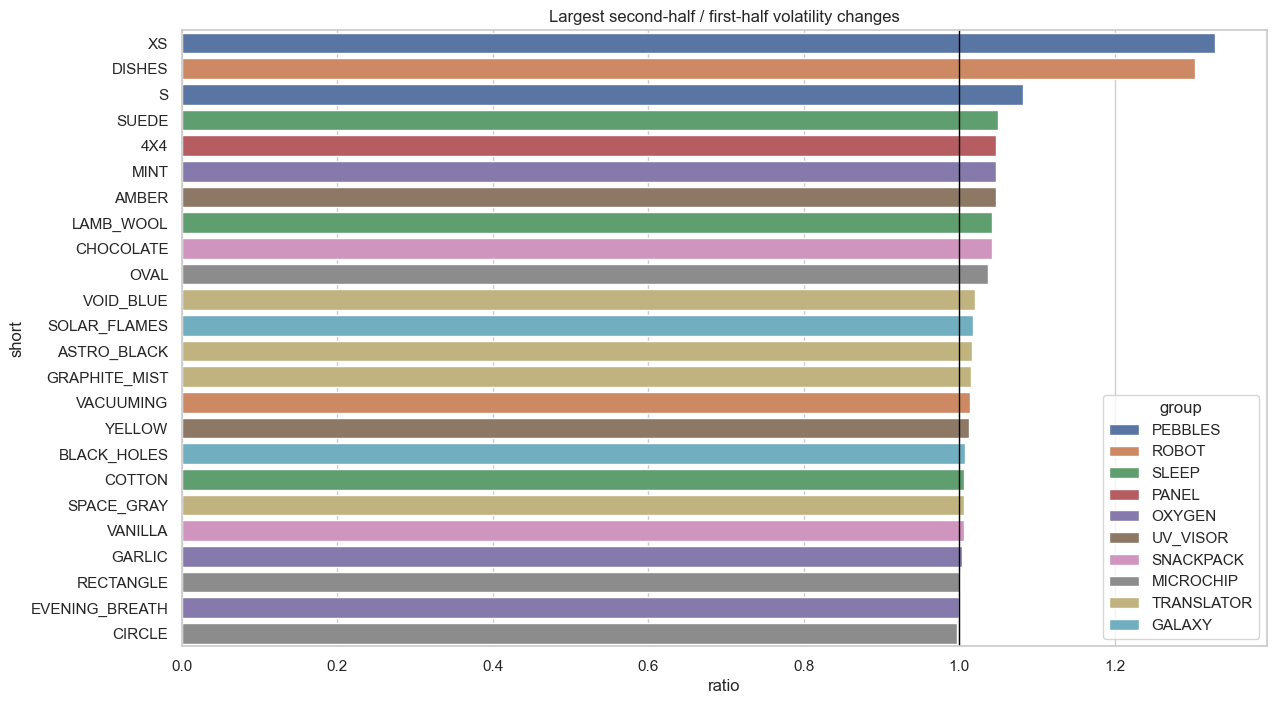

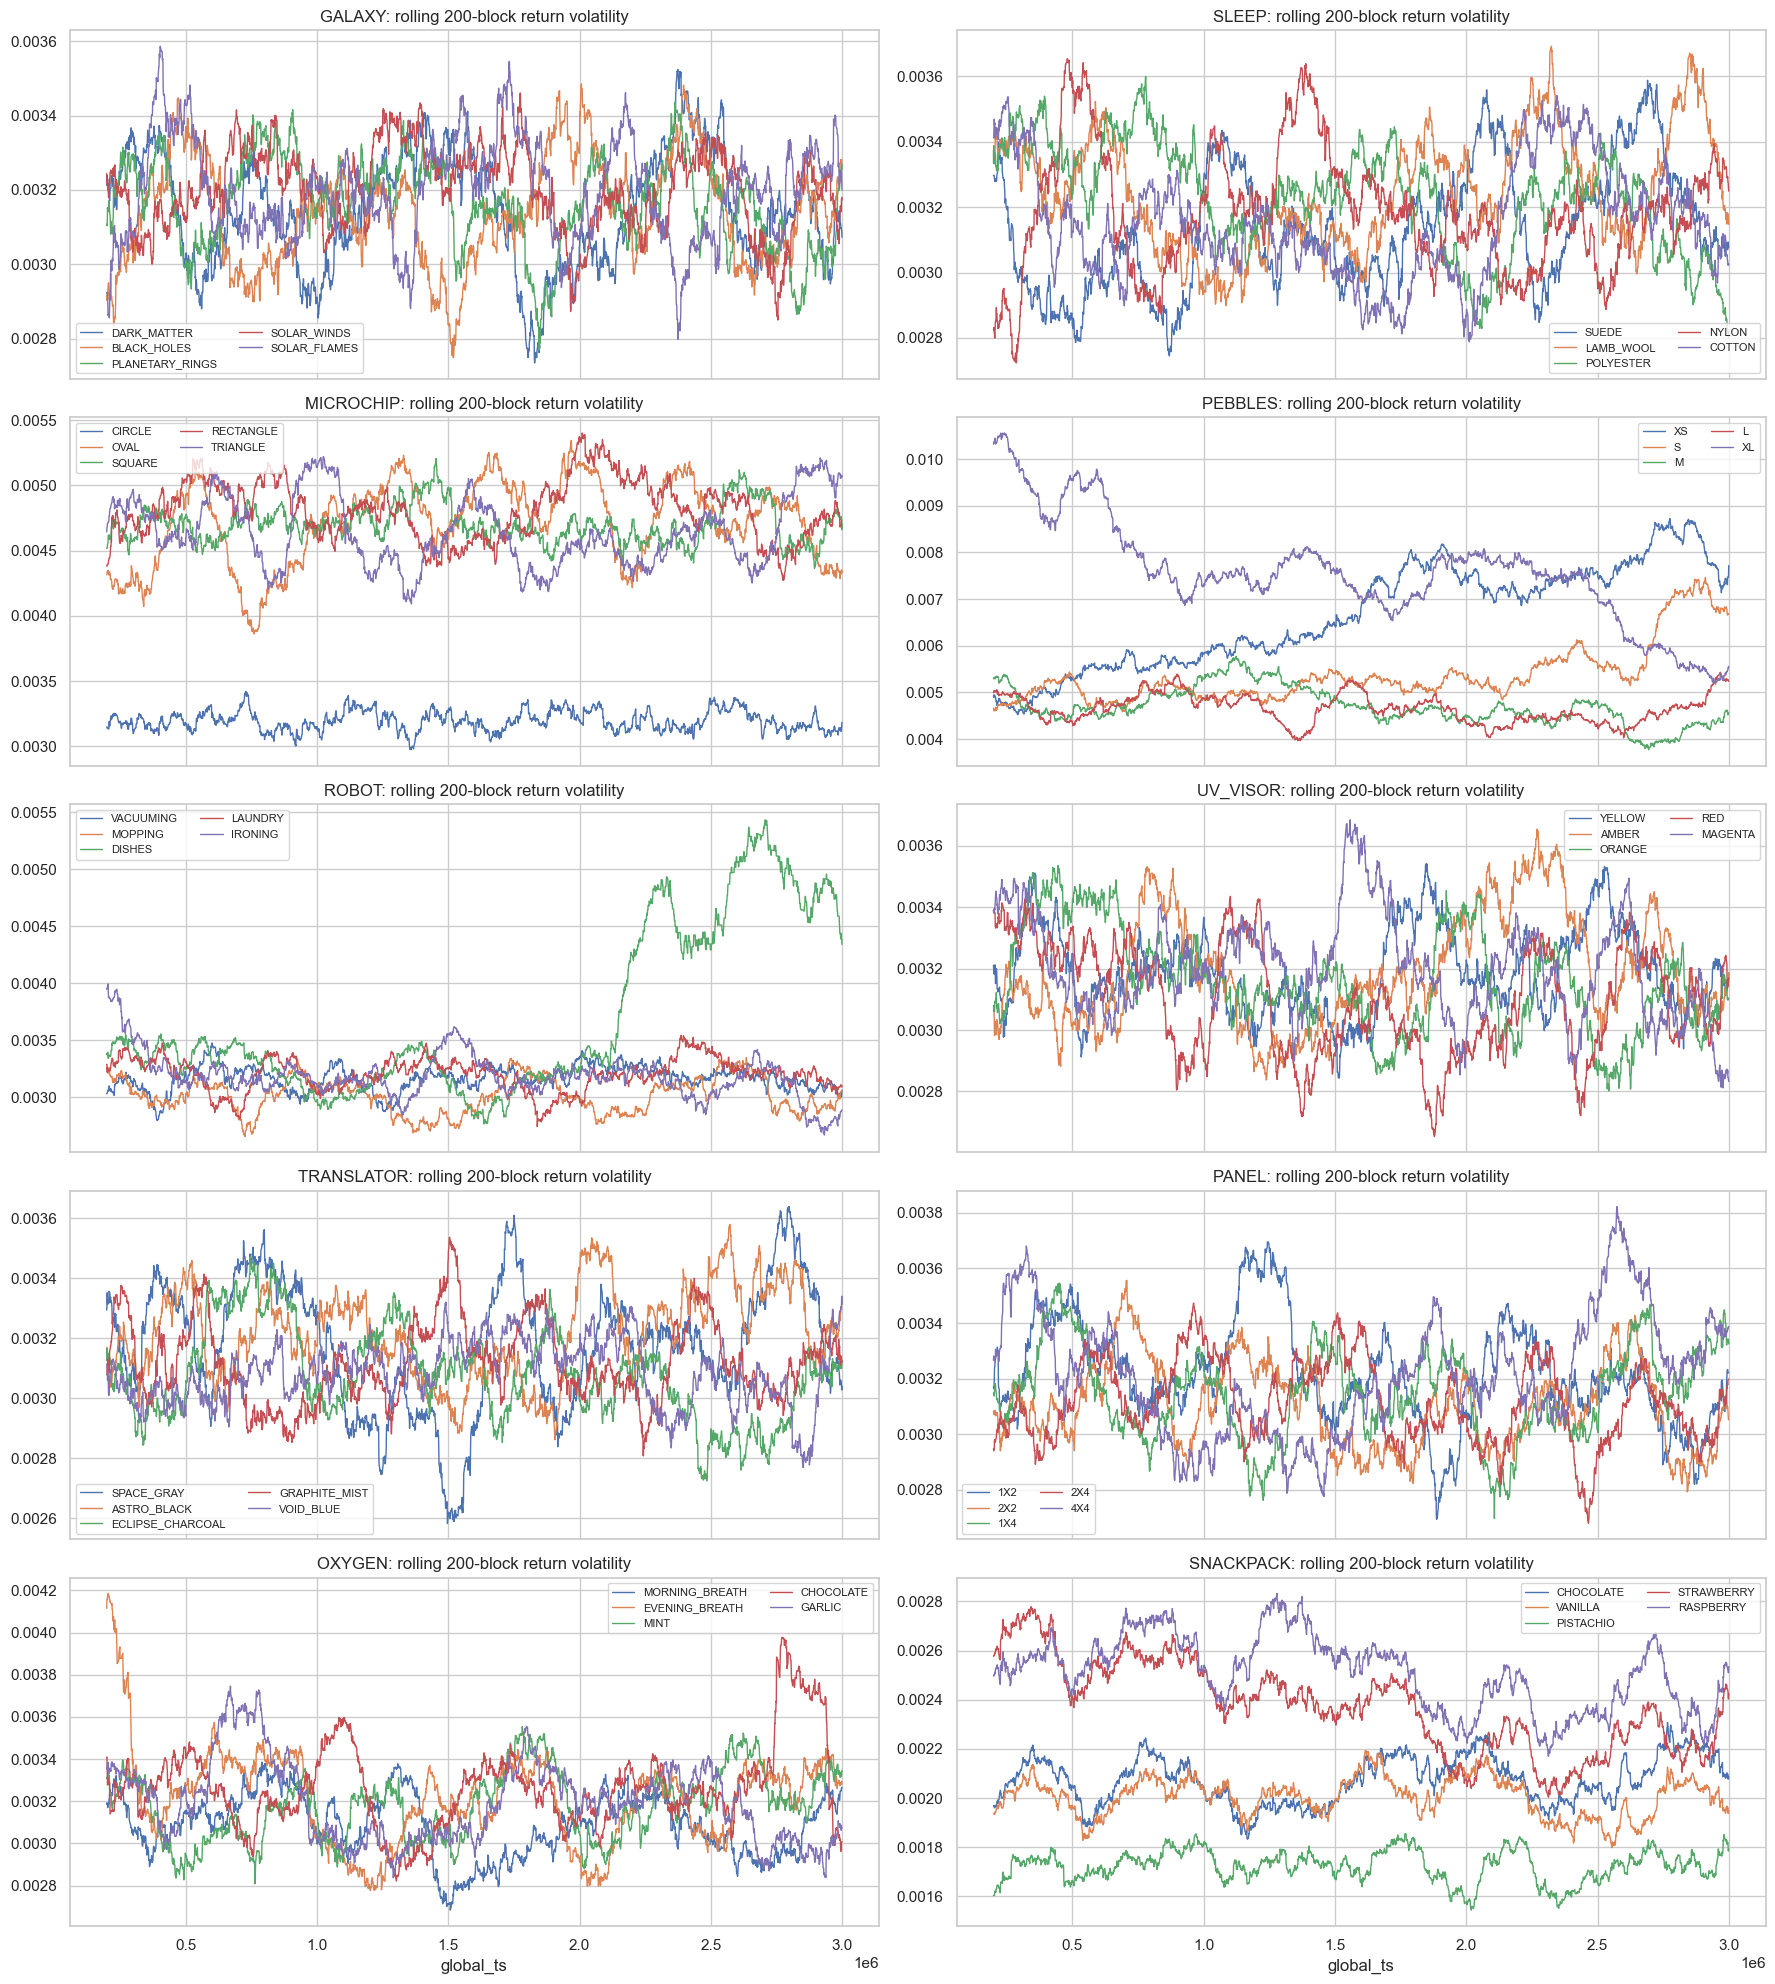

In [8]:

vol = rets_10.rolling(200).std()
vol_ratio_rows = []
for p in PRODUCTS:
    first = vol[p].iloc[: len(vol)//2].median()
    second = vol[p].iloc[len(vol)//2 :].median()
    vol_ratio_rows.append({"group": PRODUCT_TO_GROUP[p], "product": p, "short": short(p), "first_half_vol": first, "second_half_vol": second, "ratio": second / first})
vol_ratio = pd.DataFrame(vol_ratio_rows).sort_values("ratio", ascending=False)
display(vol_ratio.head(25))

plt.figure(figsize=(14, 8))
sns.barplot(data=vol_ratio.head(25), x="ratio", y="short", hue="group", dodge=False)
plt.axvline(1, color="black", linewidth=1)
plt.title("Largest second-half / first-half volatility changes")
plt.show()

fig, axes = plt.subplots(5, 2, figsize=(18, 20), sharex=True)
axes = axes.ravel()
for ax, (group, products) in zip(axes, GROUPS.items()):
    vol[products].rename(columns=short).plot(ax=ax, linewidth=1)
    ax.set_title(f"{group}: rolling 200-block return volatility")
    ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()
